In [5]:
# Download Stock Data

import yfinance as yf
import pandas as pd

data = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333870  72.394078  71.091176  71.344047  135480400
2020-01-03  71.630638  72.389257  71.406666  71.563205  146322800
2020-01-06  72.201408  72.239942  70.503546  70.754014  118387200
2020-01-07  71.861839  72.466322  71.642681  72.211041  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [6]:
# Create Moving Averages

data['SMA_10'] = data['Close'].rolling(10).mean()

data['SMA_50'] = data['Close'].rolling(50).mean()

In [7]:
# Generate Buy/Sell Signals

data['Signal'] = 0

data.loc[
    data['SMA_10'] > data['SMA_50'],
    'Signal'
] = 1

data.loc[
    data['SMA_10'] < data['SMA_50'],
    'Signal'
] = -1


# Signal	Meaning
# 1	Buy
# -1	Sell
# 0	Neutral

In [9]:
# Detect Actual Crossovers

data['Position'] = data['Signal'].diff()

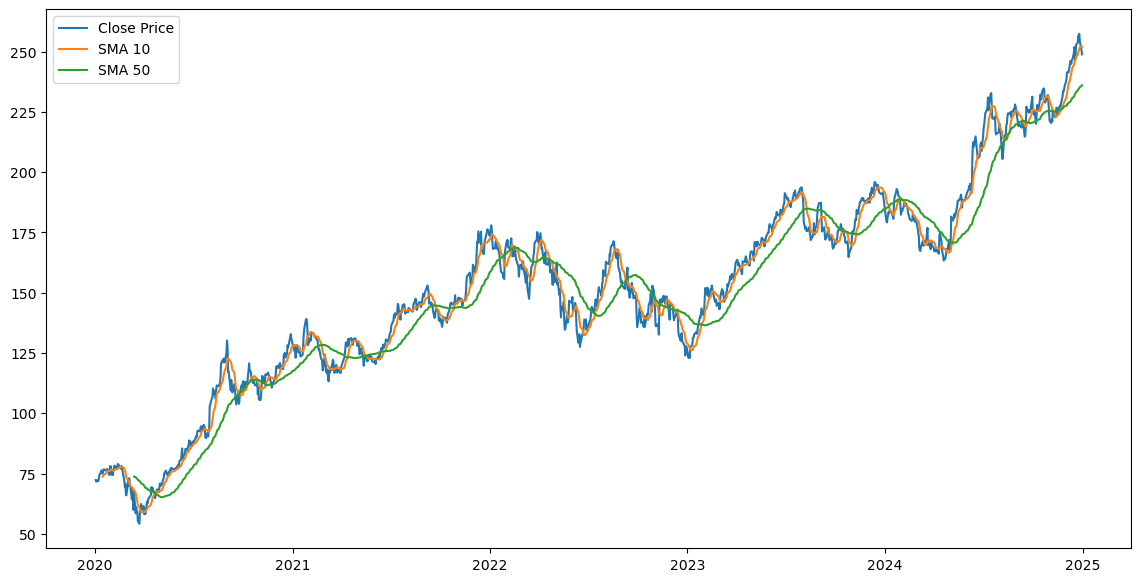

In [10]:
# Visualize Strategy

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(data['Close'], label='Close Price')

plt.plot(data['SMA_10'], label='SMA 10')

plt.plot(data['SMA_50'], label='SMA 50')

plt.legend()

plt.show()

In [11]:
# Plot Buy/Sell Points

"""
Value	    Meaning
    2	    Buy crossover
   -2	    Sell crossover
"""

buy_signals = data[data['Position'] == 2]

sell_signals = data[data['Position'] == -2]

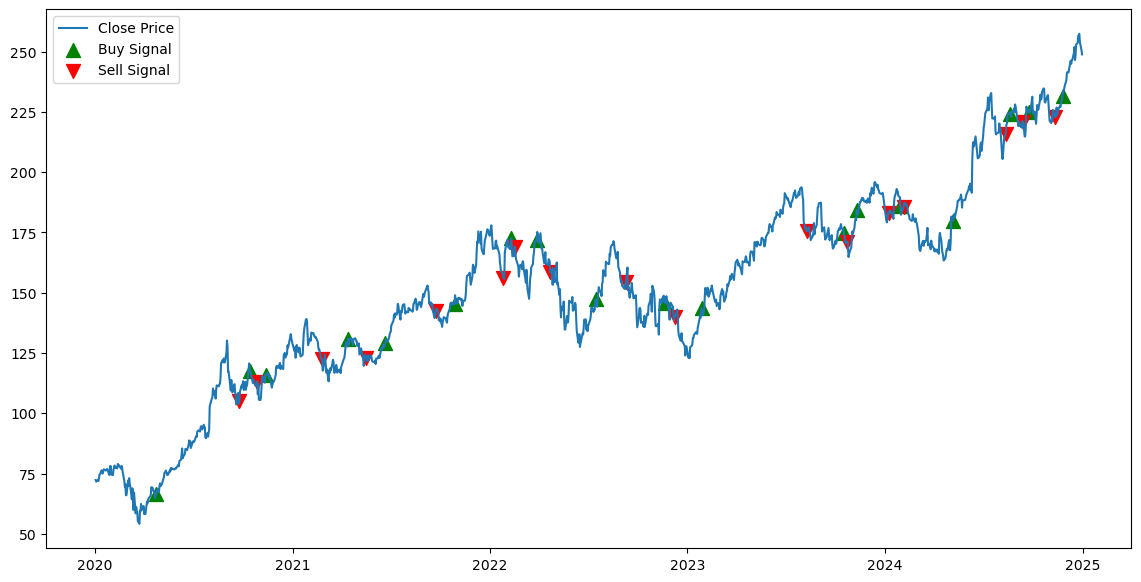

'\n     Graph Interpretation\n     \n    Element\t                Meaning\n    Blue line\t            Stock close price\n    ▲ Upward triangle\t    BUY signal (Green)\n    ▼ Downward triangle\t    SELL signal (Red)\n    \n1. Understanding ▲ BUY Signals:\n    The upward triangle means: SMA 10 crossed ABOVE SMA 50\n\n    Meaning:\n        short-term trend became stronger\n        bullish momentum increasing\n\n    So strategy says: BUY\n    \n\n2. Understanding ▼ SELL Signals:\n    The downward triangle means: SMA 10 crossed BELOW SMA 50\n\n    Meaning:\n        short-term weakness started\n        bearish momentum increasing\n\n    So strategy says: SELL\n'

In [27]:

plt.figure(figsize=(14,7))

# Stock close price
plt.plot(data['Close'], label='Close Price')


plt.scatter(
    buy_signals.index,
    buy_signals['Close'],
    marker='^',
    color='green',
    s=100,
    label='Buy Signal'
)


plt.scatter(
    sell_signals.index,
    sell_signals['Close'],
    marker='v',
    color='red',
    s=100,
    label='Sell Signal'
)

plt.legend()

plt.show()

"""
     Graph Interpretation
     
    Element	                Meaning
    Blue line	            Stock close price
    ▲ Upward triangle	    BUY signal (Green)
    ▼ Downward triangle	    SELL signal (Red)
    
1. Understanding ▲ BUY Signals:
    The upward triangle means: SMA 10 crossed ABOVE SMA 50

    Meaning:
        short-term trend became stronger
        bullish momentum increasing

    So strategy says: BUY
    

2. Understanding ▼ SELL Signals:
    The downward triangle means: SMA 10 crossed BELOW SMA 50

    Meaning:
        short-term weakness started
        bearish momentum increasing

    So strategy says: SELL
"""

In [13]:
# Simple Backtesting
# Now calculate returns.

data['Market_Return'] = data['Close'].pct_change()

data['Strategy_Return'] = (
    data['Market_Return']
    * data['Signal'].shift(1)
)

In [15]:
# Cumulative Returns

data['Cumulative_Market'] = (
    1 + data['Market_Return']
).cumprod()

data['Cumulative_Strategy'] = (
    1 + data['Strategy_Return']
).cumprod()

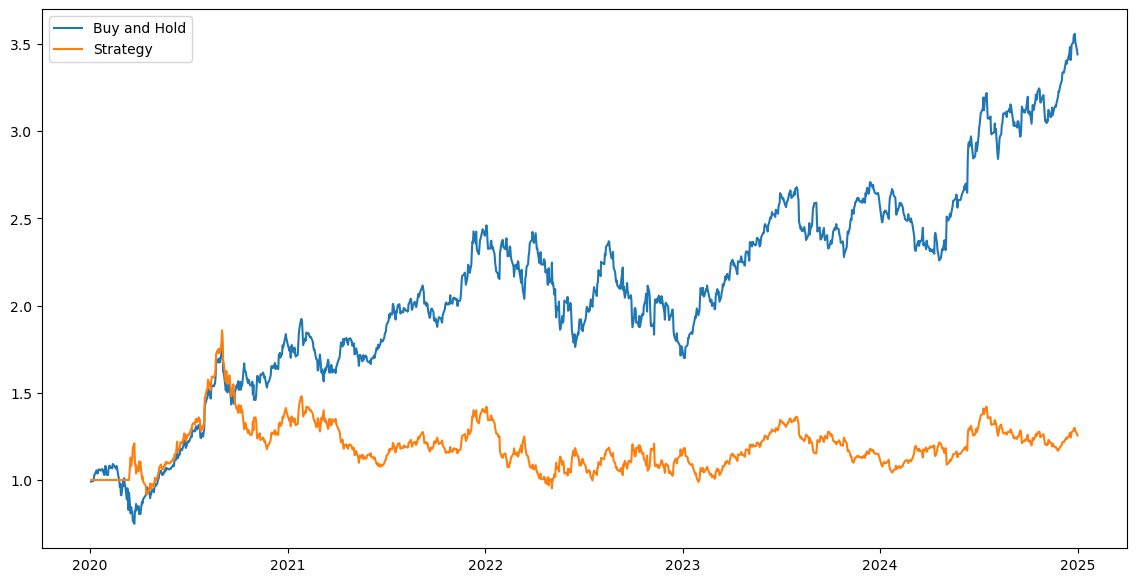

In [16]:
# Compare Performance

plt.figure(figsize=(14,7))

plt.plot(
    data['Cumulative_Market'],
    label='Buy and Hold'
)

plt.plot(
    data['Cumulative_Strategy'],
    label='Strategy'
)

plt.legend()

plt.show()

In [23]:
# Total Market Return (%)
market_return = (
    data['Cumulative_Market'].iloc[-1] - 1
) * 100

print("Market Return (%):", market_return)

Market Return (%): 244.00235419570478


In [20]:
# Total Strategy Return (%)
strategy_return = (
    data['Cumulative_Strategy'].iloc[-1] - 1
) * 100

print("Strategy Return (%):", strategy_return)

Strategy Return (%): 25.497606681451824


In [24]:
# Initial investment amount
initial_capital = 100000  # ₹1 lakh

# Final market portfolio value
final_market_value = (
    initial_capital *
    data['Cumulative_Market'].iloc[-1]
)

# Final strategy portfolio value
final_strategy_value = (
    initial_capital *
    data['Cumulative_Strategy'].iloc[-1]
)

# Percentage returns
market_return_pct = (
    data['Cumulative_Market'].iloc[-1] - 1
) * 100

strategy_return_pct = (
    data['Cumulative_Strategy'].iloc[-1] - 1
) * 100

# Profit amount
market_profit = (
    final_market_value - initial_capital
)

strategy_profit = (
    final_strategy_value - initial_capital
)

# Print results
print("=" * 50)

print("INITIAL CAPITAL: ₹", initial_capital)

print("=" * 50)

print("BUY & HOLD RESULTS")
print(f"Final Amount: ₹{final_market_value:.2f}")
print(f"Profit: ₹{market_profit:.2f}")
print(f"Return: {market_return_pct:.2f}%")

print("=" * 50)

print("STRATEGY RESULTS")
print(f"Final Amount: ₹{final_strategy_value:.2f}")
print(f"Profit: ₹{strategy_profit:.2f}")
print(f"Return: {strategy_return_pct:.2f}%")

print("=" * 50)

INITIAL CAPITAL: ₹ 100000
BUY & HOLD RESULTS
Final Amount: ₹344002.35
Profit: ₹244002.35
Return: 244.00%
STRATEGY RESULTS
Final Amount: ₹125497.61
Profit: ₹25497.61
Return: 25.50%
